Cell 1: Khởi tạo và Cấu hình

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Mount Google Drive
drive.mount('/content/drive')

# Cấu hình
DATA_PATH = '/content/drive/MyDrive/Dataset vehicle'
CATEGORIES = ['Truck', 'Motorcycle', 'Car', 'Bus']
IMG_SIZE = (64, 64)
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("Đã khởi tạo môi trường xong!")

Mounted at /content/drive
Đã khởi tạo môi trường xong!


Cell 2: Hàm HOG thủ công

In [2]:
def compute_hog(image_path, cell_size=8, block_size=2, bins=9):

    # 1. Đọc ảnh và Resize
    img = Image.open(image_path).convert('L') # Chuyển xám
    img = img.resize(IMG_SIZE, Image.BILINEAR)
    img = np.array(img, dtype=np.float32)

    # 2. Tính Gradient (Đạo hàm hướng X, Y)
    gx = np.zeros_like(img); gy = np.zeros_like(img)
    gx[:, :-1] = img[:, 1:] - img[:, :-1] # Trừ cột sau cho cột trước
    gy[:-1, :] = img[1:, :] - img[:-1, :] # Trừ hàng dưới cho hàng trên

    # 3. Tính Magnitude (Độ lớn) và Angle (Góc)
    mag = np.hypot(gx, gy)
    ang = np.degrees(np.arctan2(gy, gx)) % 180.0 # Góc 0-180 độ

    # 4. Tính Histogram cho từng Cell (Có nội suy - Interpolation)
    h, w = img.shape
    n_cells_y, n_cells_x = h // cell_size, w // cell_size
    cell_hist = np.zeros((n_cells_y, n_cells_x, bins))
    bin_width = 180.0 / bins

    # Duyệt qua từng cell (Phần này hơi chậm nhưng chính xác về toán học)
    for i in range(n_cells_y):
        for j in range(n_cells_x):
            # Lấy vùng dữ liệu của cell
            c_mag = mag[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size].flatten()
            c_ang = ang[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size].flatten()

            # Bỏ phiếu vào histogram (Voting)
            for m, a in zip(c_mag, c_ang):
                ratio = a / bin_width
                idx_1 = int(np.floor(ratio)) % bins
                idx_2 = (idx_1 + 1) % bins
                weight_2 = ratio - int(ratio) # Phần lẻ
                weight_1 = 1.0 - weight_2     # Phần nguyên

                cell_hist[i, j, idx_1] += m * weight_1
                cell_hist[i, j, idx_2] += m * weight_2

    # 5. Block Normalization (Chuẩn hóa khối)
    hog_vector = []
    for i in range(n_cells_y - block_size + 1):
        for j in range(n_cells_x - block_size + 1):
            block = cell_hist[i:i+block_size, j:j+block_size, :].flatten()
            # L2 Norm
            norm_val = np.sqrt(np.sum(block**2) + 1e-5)
            hog_vector.extend(block / norm_val)

    return np.array(hog_vector, dtype=np.float32)

print("Đã xây dựng xong hàm HOG thủ công!")

Đã xây dựng xong hàm HOG thủ công!


Cell 3: Data Pipeline (Load -> HOG -> Split -> Scale)

In [3]:
print("Đang xử lý dữ liệu (Load -> HOG)...")

X_list = []
y_list = []
paths_list = []

# Duyệt qua các thư mục
for idx, category in enumerate(CATEGORIES):
    folder_path = os.path.join(DATA_PATH, category)
    if not os.path.exists(folder_path): continue

    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('jpg','jpeg','png'))]
    print(f"- Đang xử lý lớp {category}: {len(files)} ảnh")

    for filename in files:
        img_path = os.path.join(folder_path, filename)
        try:
            # Gọi hàm HOG ở trên
            features = compute_hog(img_path)

            X_list.append(features)
            y_list.append(idx)
            paths_list.append(img_path)
        except Exception as e:
            pass

X = np.array(X_list)
y = np.array(y_list)
paths = np.array(paths_list)

# Chia Train/Test (80-20)
# stratify=y để đảm bảo tỉ lệ các lớp đều nhau
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, paths, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Chuẩn hóa dữ liệu (StandardScaler cực quan trọng cho SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nHoàn tất! Train: {X_train.shape[0]} ảnh, Test: {X_test.shape[0]} ảnh")
print(f"Số chiều đặc trưng (Features): {X.shape[1]}")

Đang xử lý dữ liệu (Load -> HOG)...
- Đang xử lý lớp Truck: 100 ảnh


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


- Đang xử lý lớp Motorcycle: 100 ảnh
- Đang xử lý lớp Car: 100 ảnh
- Đang xử lý lớp Bus: 100 ảnh

Hoàn tất! Train: 320 ảnh, Test: 80 ảnh
Số chiều đặc trưng (Features): 1764


Cell 4: Huấn luyện SVM RBF

Đang huấn luyện SVM RBF...

>>> ĐỘ CHÍNH XÁC (SVM RBF): 0.7125
----------------------------------------
              precision    recall  f1-score   support

       Truck       0.50      0.55      0.52        20
  Motorcycle       0.95      0.90      0.92        20
         Car       0.83      0.75      0.79        20
         Bus       0.62      0.65      0.63        20

    accuracy                           0.71        80
   macro avg       0.72      0.71      0.72        80
weighted avg       0.72      0.71      0.72        80



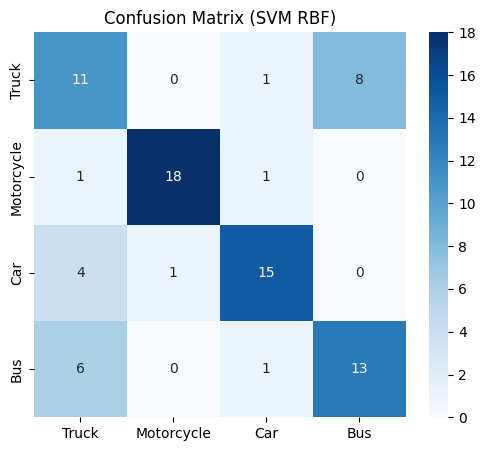

In [5]:
print("Đang huấn luyện SVM RBF...")

# Cấu hình SVM RBF
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RANDOM_SEED)
svm.fit(X_train_s, y_train)

# Đánh giá
y_pred = svm.predict(X_test_s)
acc_baseline = accuracy_score(y_test, y_pred)

print(f"\n>>> ĐỘ CHÍNH XÁC (SVM RBF): {acc_baseline:.4f}")
print("-" * 40)
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix (SVM RBF)')
plt.show()

Cell 5: Phân tích PCA

Đang chạy thử nghiệm PCA...
Components      | Accuracy  
------------------------------
10              | 0.5375
20              | 0.6250
50              | 0.6625
100             | 0.6500
200             | 0.7000


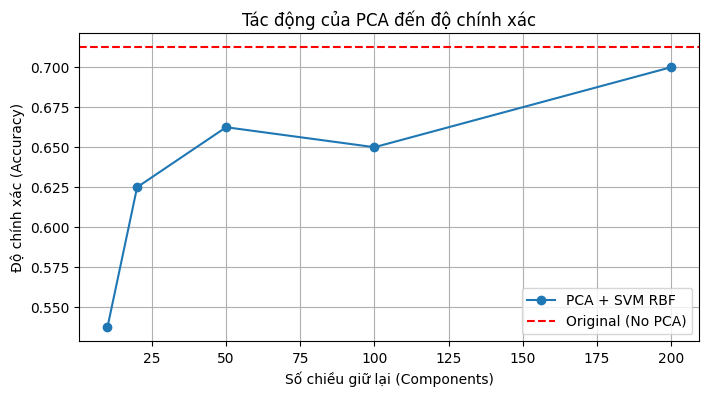

In [ ]:
print("Đang chạy thử nghiệm PCA...")

pca_comps = [10, 20, 50, 100, 200] # Các mốc số chiều muốn thử
results = []

print(f"{'Components':<15} | {'Accuracy':<10}")
print("-" * 30)

for n in pca_comps:
    if n > X_train_s.shape[1]: continue

    # 1. Giảm chiều dữ liệu
    pca = PCA(n_components=n, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    # 2. Train SVM trên dữ liệu nén
    clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RANDOM_SEED)
    clf.fit(X_train_pca, y_train)

    # 3. Ghi nhận kết quả
    acc = clf.score(X_test_pca, y_test)
    results.append(acc)
    print(f"{n:<15} | {acc:.4f}")

# Vẽ biểu đồ đường
plt.figure(figsize=(8, 4))
plt.plot(pca_comps[:len(results)], results, marker='o', label='PCA + SVM RBF')
plt.axhline(y=acc_baseline, color='r', linestyle='--', label='Original (No PCA)')
plt.xlabel('Số chiều giữ lại (Components)')
plt.ylabel('Độ chính xác (Accuracy)')
plt.title('Tác động của PCA đến độ chính xác')
plt.legend()
plt.grid(True)
plt.show()

Cell 6: Hiển thị kết quả thực tế

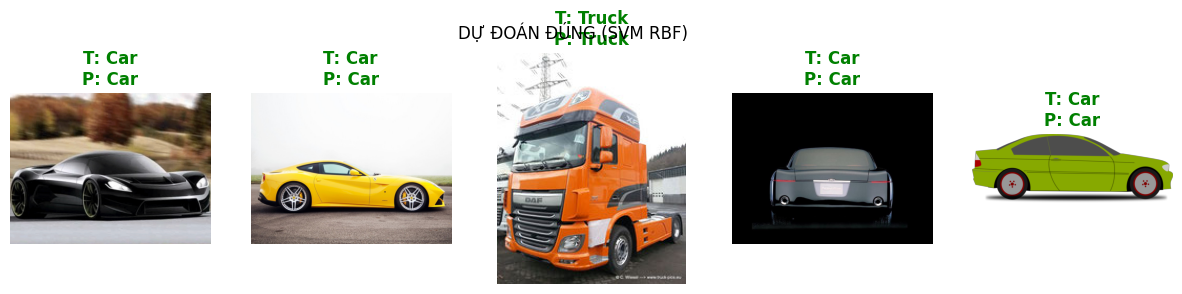

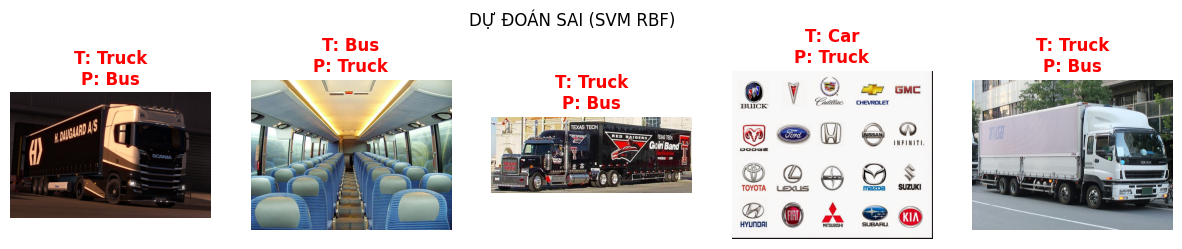

In [6]:
def show_samples(indices, title, color):
    if len(indices) == 0: return
    plt.figure(figsize=(15, 3))
    # Chọn ngẫu nhiên tối đa 5 ảnh
    show_idx = np.random.choice(indices, min(len(indices), 5), replace=False)

    for i, idx in enumerate(show_idx):
        path = paths_test[idx]
        # Đọc ảnh gốc để hiển thị
        img = Image.open(path)

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"T: {CATEGORIES[y_test[idx]]}\nP: {CATEGORIES[y_pred[idx]]}",
                  color=color, fontweight='bold')
    plt.suptitle(title)
    plt.show()

# Lọc đúng sai từ kết quả của model SVM RBF (Cell 4)
correct_idx = np.where(y_test == y_pred)[0]
wrong_idx = np.where(y_test != y_pred)[0]

show_samples(correct_idx, "DỰ ĐOÁN ĐÚNG (SVM RBF)", 'green')
show_samples(wrong_idx, "DỰ ĐOÁN SAI (SVM RBF)", 'red')